# 17.9 Generative Adversarial Networks

#### Data

2023-08-06 11:09:18.817986: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


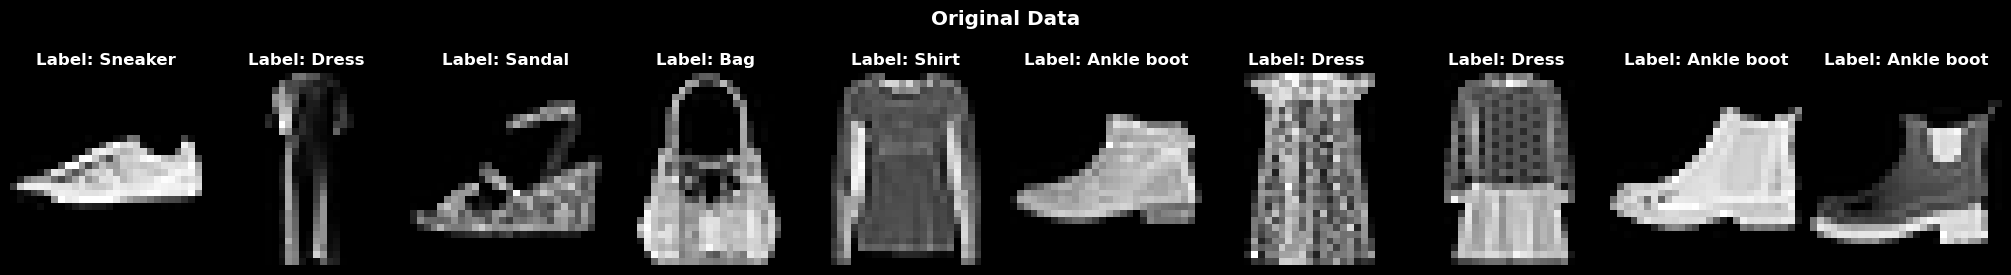

In [1]:
import load_fashion_mnist

(
    (x_train_norm, y_train),
    (x_valid_norm, y_valid),
    (x_test_norm, y_test),
) = load_fashion_mnist.load_data()

In [2]:
x_train_norm.shape

(48000, 28, 28)

In [3]:
x_train_norm.dtype

dtype('float64')

#### Model

In [4]:
import tensorflow as tf

coding_size = 30

generator = tf.keras.models.Sequential(
    [
        tf.keras.layers.Dense(
            coding_size, activation="selu", kernel_initializer="lecun_normal", input_shape=(coding_size,)
        ),
        tf.keras.layers.Dense(100, activation="selu", kernel_initializer="lecun_normal"),
        tf.keras.layers.Dense(150, activation="selu", kernel_initializer="lecun_normal"),
        tf.keras.layers.Dense(784, activation="sigmoid"),
        tf.keras.layers.Reshape((28, 28)),
    ]
)

discriminator = tf.keras.models.Sequential(
    [
        tf.keras.layers.Flatten(input_shape=(28, 28)),
        tf.keras.layers.Dense(150, activation="selu", kernel_initializer="lecun_normal"),
        tf.keras.layers.Dense(100, activation="selu", kernel_initializer="lecun_normal"),
        tf.keras.layers.Dense(1, activation="sigmoid"),
    ]
)

gan = tf.keras.models.Sequential([generator, discriminator])

2023-08-06 11:09:23.471505: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-08-06 11:09:23.517022: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-08-06 11:09:23.517487: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-08-06 11:09:23.518158: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropri

In [5]:

discriminator.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
discriminator.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   


 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense_4 (Dense)             (None, 150)               117750    
                                                                 
 dense_5 (Dense)             (None, 100)               15100     
                                                                 
 dense_6 (Dense)             (None, 1)                 101       
                                                                 
Total params: 132,951
Trainable params: 132,951
Non-trainable params: 0
_________________________________________________________________


In [6]:
discriminator.trainable = False
gan.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
gan.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential (Sequential)     (None, 28, 28)            137564    
                                                                 
 sequential_1 (Sequential)   (None, 1)                 132951    
                                                                 
Total params: 270,515
Trainable params: 137,564
Non-trainable params: 132,951
_________________________________________________________________


#### Training

In [7]:
import numpy as np

batch_size = 32
ds_train = tf.data.Dataset.from_tensor_slices(x_train_norm.astype(np.float32)).shuffle(1000)
ds_train = ds_train.batch(batch_size=batch_size, drop_remainder=True).prefetch(1)

In [8]:
import tqdm

def train_gan(
    gan: tf.keras.models.Model, dataset: tf.data.Dataset, coding_size: int, batch_size: int, n_epochs: int = 50
) -> None:
    generator, discriminator = gan.layers

    for epoch in tqdm.tqdm(range(n_epochs), desc="Epoch", total=n_epochs):
        for x_real in tqdm.tqdm(dataset, desc="Batch"):
            # Phase 1: train discriminator
            codings = tf.random.normal(shape=(batch_size, coding_size))
            x_fake = generator(codings)
            x_real_and_fake = tf.concat([x_real, x_fake], axis=0)
            y_real_and_fake = tf.constant([[1.]] * batch_size + [[0.]] * batch_size)

            discriminator.trainable = True
            discriminator.train_on_batch(x_real_and_fake, y_real_and_fake)

            # Phase 2: train generator
            codings = tf.random.normal(shape=(batch_size, coding_size))
            y_counterfeit = tf.constant([[1.]] * batch_size)

            discriminator.trainable = False
            gan.train_on_batch(codings, y_counterfeit)


train_gan(
    gan=gan,
    dataset=ds_train,
    coding_size=coding_size,
    batch_size=batch_size,
    n_epochs=3,
)

Epoch:   0%|          | 0/3 [00:00<?, ?it/s]2023-08-06 11:09:29.686278: W tensorflow/core/data/root_dataset.cc:266] Optimization loop failed: CANCELLED: Operation was cancelled
2023-08-06 11:09:31.441631: W tensorflow/core/data/root_dataset.cc:266] Optimization loop failed: CANCELLED: Operation was cancelled
2023-08-06 11:09:36.937338: W tensorflow/core/data/root_dataset.cc:266] Optimization loop failed: CANCELLED: Operation was cancelled
2023-08-06 11:09:46.077216: W tensorflow/core/data/root_dataset.cc:266] Optimization loop failed: CANCELLED: Operation was cancelled
Epoch:  67%|██████▋   | 2/3 [01:16<00:38, 38.09s/it]2023-08-06 11:10:42.835753: W tensorflow/core/data/root_dataset.cc:266] Optimization loop failed: CANCELLED: Operation was cancelled
2023-08-06 11:11:14.821749: W tensorflow/core/data/root_dataset.cc:266] Optimization loop failed: CANCELLED: Operation was cancelled
Epoch: 100%|██████████| 3/3 [01:52<00:00, 37.37s/it]


#### Application

1/1 [==============================] - 0s 136ms/step


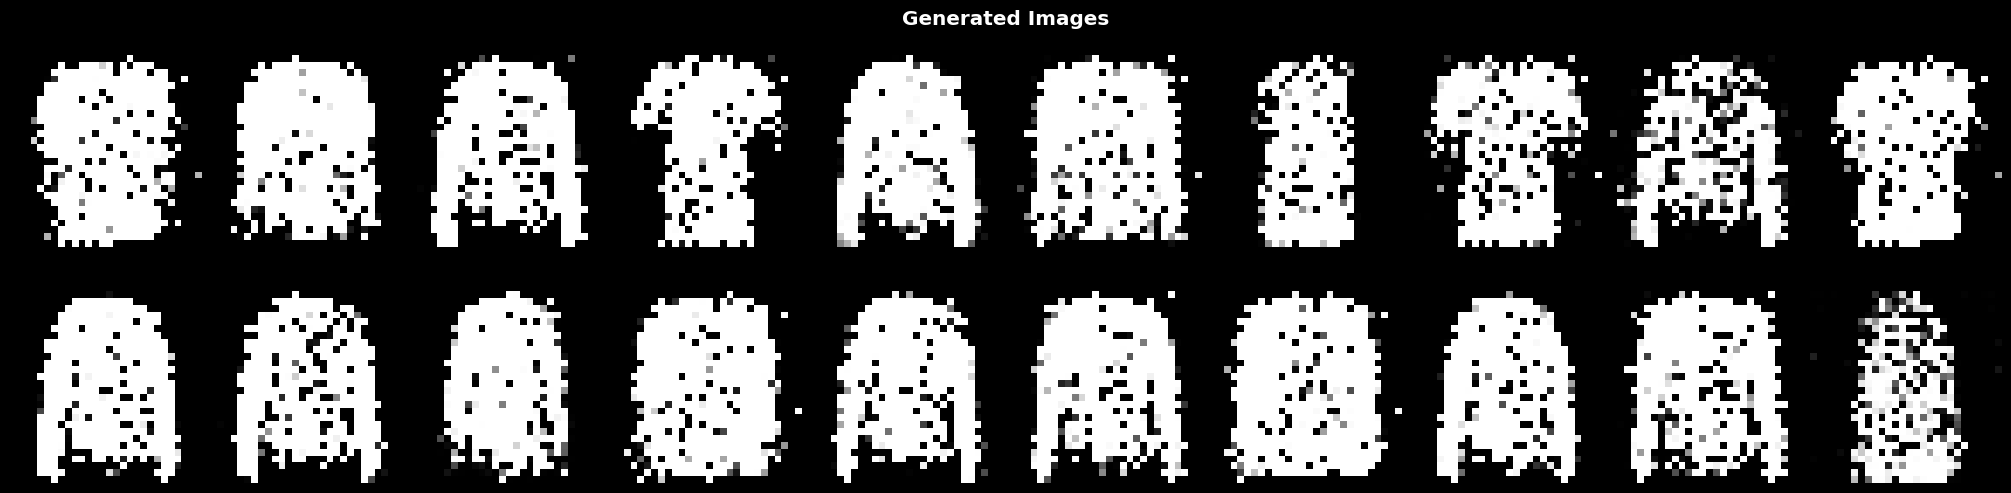

In [9]:
import plot_images

n_samples = 20
noise = tf.random.normal(shape=(n_samples, coding_size))
images = generator.predict(noise)
plot_images.plot_images(images_norm=images, sup_title="Generated Images")